# CNG403 Assignment 1 — Feed-Forward Neural Network from Scratch

**Objective**: Implement a complete FFNN using only raw PyTorch tensors and verify that it produces results consistent with the PyTorch `nn.Module` reference implementation.

**Workflow**:
1. [Setup](#1-setup)
2. [Data & Feature Extraction](#2-data--feature-extraction)
3. [Reference Model (nn.Module)](#3-reference-model-nnmodule)
4. [Scratch Implementation — Layers](#4-scratch-implementation--layers)
5. [Scratch Implementation — Network & Optimisers](#5-scratch-implementation--network--optimisers)
6. [Training the Scratch Model](#6-training-the-scratch-model)
7. [Comparison & Results](#7-comparison--results)
8. [Hyperparameter Tuning](#8-hyperparameter-tuning)

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, 'src')   # so we can import from src/

import json
import numpy as np
import torch
import matplotlib.pyplot as plt

print('PyTorch version:', torch.__version__)
print('Device:', 'cuda' if torch.cuda.is_available() else 'cpu')

PyTorch version: 2.10.0
Device: cpu


In [2]:
# Load configs
with open('configs/reference_config.json') as f:
    ref_cfg = json.load(f)

with open('configs/scratch_config.json') as f:
    scr_cfg = json.load(f)

print('Reference config:', json.dumps(ref_cfg, indent=2))

Reference config: {
  "data": {
    "root": "data/",
    "feature_type": "hog",
    "hog": {
      "orientations": 9,
      "pixels_per_cell": [
        8,
        8
      ],
      "cells_per_block": [
        2,
        2
      ]
    },
    "val_split": 0.1
  },
  "model": {
    "hidden_sizes": [
      256,
      128
    ],
    "activation": "relu",
    "dropout": 0.0
  },
  "training": {
    "optimizer": "sgd",
    "learning_rate": 0.01,
    "momentum": 0.9,
    "batch_size": 64,
    "epochs": 20,
    "l2_lambda": 0.0001,
    "seed": 42
  },
  "paths": {
    "checkpoint_dir": "checkpoints/",
    "log_dir": "logs/"
  }
}


## 2. Data & Feature Extraction

MNIST images are 28×28 grayscale pixels. Instead of feeding raw pixels into the network, we extract **HOG (Histogram of Oriented Gradients)** features — a classical computer vision descriptor that captures edge and texture information.

HOG parameters (from config):
- `orientations`: number of gradient orientation bins
- `pixels_per_cell`: size of each cell in pixels
- `cells_per_block`: number of cells per normalisation block

In [3]:
from reference import load_and_extract, set_seed

set_seed(ref_cfg['training']['seed'])
X_train, y_train, X_val, y_val, X_test, y_test = load_and_extract(ref_cfg['data'])

print(f'Train : {X_train.shape}  labels: {y_train.shape}')
print(f'Val   : {X_val.shape}  labels: {y_val.shape}')
print(f'Test  : {X_test.shape}  labels: {y_test.shape}')
print(f'Feature dim: {X_train.shape[1]}')

100.0%
100.0%
100.0%
100.0%


Extracting HOG features (train)…
Extracting HOG features (test)…
Train : torch.Size([54000, 144])  labels: torch.Size([54000])
Val   : torch.Size([6000, 144])  labels: torch.Size([6000])
Test  : torch.Size([10000, 144])  labels: torch.Size([10000])
Feature dim: 144


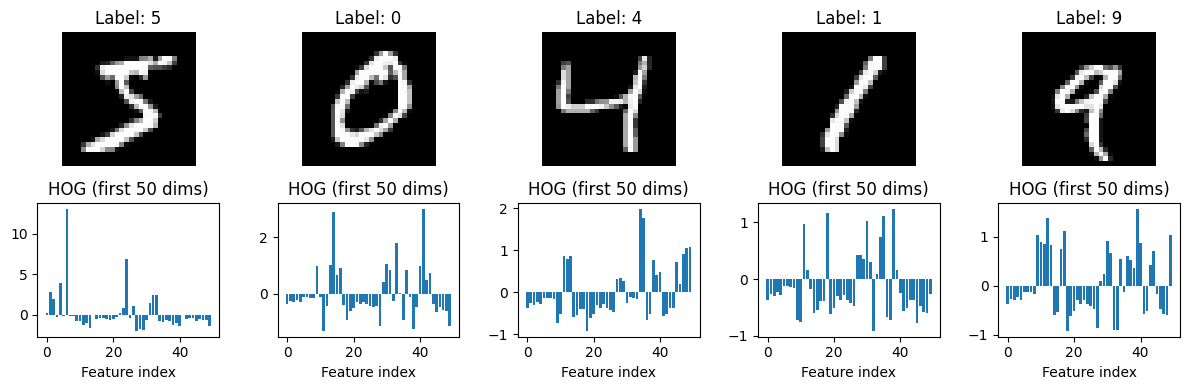

In [4]:
# Visualise a few HOG feature vectors
fig, axes = plt.subplots(2, 5, figsize=(12, 4))
from torchvision import datasets
import torchvision.transforms as T

raw = datasets.MNIST(ref_cfg['data']['root'], train=True, download=True, transform=T.ToTensor())

for i, ax in enumerate(axes[0]):
    ax.imshow(raw[i][0].squeeze(), cmap='gray')
    ax.set_title(f'Label: {raw[i][1]}')
    ax.axis('off')

for i, ax in enumerate(axes[1]):
    ax.bar(range(min(50, X_train.shape[1])), X_train[i, :50].numpy())
    ax.set_title('HOG (first 50 dims)')
    ax.set_xlabel('Feature index')

plt.tight_layout()
plt.show()

## 3. Reference Model (nn.Module)

Run the self-contained reference pipeline. This establishes the **target performance** your scratch implementation should match.

In [5]:
# Run the full reference pipeline (equivalent to: python src/reference.py)
import reference
reference.run('configs/reference_config.json')

Device: cpu
Extracting HOG features (train)…
Extracting HOG features (test)…
Train: torch.Size([54000, 144])  Val: torch.Size([6000, 144])  Test: torch.Size([10000, 144])

Model:
Sequential(
  (0): Linear(in_features=144, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=10, bias=True)
)

Epoch   1/20  train_loss=0.3590  train_acc=0.8955  val_loss=0.1471  val_acc=0.9512
  Checkpoint saved → checkpoints/reference_best.pt
Epoch   2/20  train_loss=0.1445  train_acc=0.9587  val_loss=0.1196  val_acc=0.9587
  Checkpoint saved → checkpoints/reference_best.pt
Epoch   3/20  train_loss=0.1172  train_acc=0.9686  val_loss=0.1016  val_acc=0.9652
  Checkpoint saved → checkpoints/reference_best.pt
Epoch   4/20  train_loss=0.1021  train_acc=0.9730  val_loss=0.0997  val_acc=0.9663
  Checkpoint saved → checkpoints/reference_best.pt
Epoch   5/20  train_loss=0.0914  train_acc=0.9766  val_loss=0.0

In [6]:
# Load and plot reference training history
ref_history = np.load('logs/reference_history.npy', allow_pickle=True).item()
print('Keys:', list(ref_history.keys()))
print('Best val acc:', max(ref_history['val_acc']))

Keys: ['train_loss', 'train_acc', 'val_loss', 'val_acc']
Best val acc: 0.9748333333333333


## 4. Scratch Implementation — Layers

Open `src/layers.py` and implement each class marked with `TODO`.

Run the cell below to check your implementation against PyTorch's reference values.

In [7]:
# Reload the module after your edits
import importlib, layers
importlib.reload(layers)
from layers import Linear, ReLU, Sigmoid, Tanh, CrossEntropyLoss

# Run the built-in sanity checks
%run src/layers.py

Sanity checks for layers.py

[Linear]


NotImplementedError: Linear.forward

### 4.1 Questions — Layers

Answer these in the cells below **before** moving on.

**Q1**: What is the gradient of ReLU at exactly x=0, and why does it not matter in practice?

**Q2**: Why do we subtract the row-max before computing softmax in `CrossEntropyLoss.forward`?

**Q3**: Why is combining softmax and cross-entropy into one step numerically better than computing them separately?

*Your answers here.*

## 5. Scratch Implementation — Network & Optimisers

Open `src/network.py` and `src/optimizers.py` and implement the `TODO` sections.

In [8]:
import importlib, network, optimizers
importlib.reload(network)
importlib.reload(optimizers)

%run src/network.py
%run src/optimizers.py

Sanity check for network.py


NotImplementedError: FFNN.__init__

Sanity check for optimizers.py

[SGD — no momentum]


NotImplementedError: FFNN.__init__

### 5.1 Questions — Network & Optimisers

**Q4**: Explain the difference between SGD, Mini-batch GD, and Batch GD. What are the trade-offs?

**Q5**: What does the L2 regularisation term add to the gradient? What effect does this have on the weights over time?

**Q6**: How does momentum help SGD? Describe intuitively what the velocity buffer represents.

*Your answers here.*

## 6. Training the Scratch Model

In [9]:
# Run the full scratch training pipeline
import train
importlib.reload(train)
train.run('configs/scratch_config.json')

Extracting HOG features (train)…
Extracting HOG features (test)…
Train: torch.Size([54000, 144])  Val: torch.Size([6000, 144])  Test: torch.Size([10000, 144])


NotImplementedError: FFNN.__init__

In [ ]:
scr_history = np.load('logs/scratch_history.npy', allow_pickle=True).item()
print('Best val acc (scratch):', max(scr_history['val_acc']))

## 7. Comparison & Results

Your scratch implementation is considered **consistent** with the reference if the final test accuracy is within ~2% under the same configuration.

In [ ]:
def plot_comparison(ref_hist, scr_hist):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for ax, metric, title in zip(
        axes,
        ['loss', 'acc'],
        ['Cross-Entropy Loss', 'Accuracy'],
    ):
        for split, ls in [('train', '--'), ('val', '-')]:
            key = f'{split}_{metric}'
            ax.plot(ref_hist[key], ls=ls, color='steelblue',  label=f'Reference {split}')
            ax.plot(scr_hist[key], ls=ls, color='darkorange', label=f'Scratch   {split}')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('logs/comparison.png', dpi=150)
    plt.show()

plot_comparison(ref_history, scr_history)

In [ ]:
# Summary table
print(f"{'Metric':<25} {'Reference':>12} {'Scratch':>12}")
print('-' * 52)
print(f"{'Best val accuracy':<25} {max(ref_history['val_acc']):>12.4f} {max(scr_history['val_acc']):>12.4f}")
print(f"{'Final train loss':<25} {ref_history['train_loss'][-1]:>12.4f} {scr_history['train_loss'][-1]:>12.4f}")
print(f"{'Final val loss':<25} {ref_history['val_loss'][-1]:>12.4f} {scr_history['val_loss'][-1]:>12.4f}")

## 8. Hyperparameter Tuning

Use the **validation set** (never the test set) to tune hyperparameters. Search over at least:
- Learning rate
- Hidden layer sizes
- Activation function
- L2 regularisation strength
- Batch size

Report your best configuration and its test accuracy **after** tuning is complete.

In [ ]:
# TODO: implement your hyperparameter search here.
#
# Suggested approach: grid search or random search.
# For each candidate config, train with train.train_one_epoch + train.evaluate
# and record the best val_acc.
#
# Example skeleton:
#
# from network import FFNN
# from optimizers import SGD
# from layers import CrossEntropyLoss
# from train import train_one_epoch, evaluate
# from torch.utils.data import DataLoader, TensorDataset
#
# search_space = {
#     'lr':         [0.1, 0.01, 0.001],
#     'hidden':     [[256, 128], [512, 256], [128]],
#     'activation': ['relu', 'tanh'],
#     'l2':         [0.0, 0.0001, 0.001],
# }
#
# results = []
# for lr in search_space['lr']:
#     for hidden in search_space['hidden']:
#         ...  # train and record val_acc

raise NotImplementedError('Implement hyperparameter search')

In [ ]:
# TODO: report your best hyperparameters and evaluate on the TEST SET
#
# IMPORTANT: only evaluate on the test set ONCE, with your final best config.
# Evaluating multiple times on the test set is data leakage.

best_config = {
    'lr':         None,   # fill in
    'hidden':     None,   # fill in
    'activation': None,   # fill in
    'l2':         None,   # fill in
    'batch_size': None,   # fill in
}

print('Best config:', best_config)
# test_loss, test_acc = evaluate(best_net, test_loader, loss_fn)
# print(f'Test accuracy: {test_acc:.4f}')

### 8.1 Tuning Analysis

**Q7**: Which hyperparameter had the biggest impact on validation accuracy? Why do you think that is?

**Q8**: Did you observe overfitting? How did regularisation affect it?

**Q9**: Compare SGD vs Batch GD in terms of convergence speed and final accuracy on this dataset.

*Your answers here.*